

## The given data
### **netflix_data.csv**
| Column | Description |
|--------|-------------|
| `show_id` | The ID of the show |
| `type` | Type of show |
| `title` | Title of the show |
| `director` | Director of the show |
| `cast` | Cast of the show |
| `country` | Country of origin |
| `date_added` | Date added to Netflix |
| `release_year` | Year of Netflix release |
| `duration` | Duration of the show in minutes |
| `description` | Description of the show |
| `genre` | Show genre |

In [30]:
# Importing pandas, numpy and matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Reading in the Netflix CSV as a DataFrame
netflix_df = pd.read_csv("netflix_data.csv")

In [45]:
# Checking the structure of the DataFrame and understanding its contents
print(netflix_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4812 entries, 0 to 4811
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       4812 non-null   object
 1   type          4812 non-null   object
 2   title         4812 non-null   object
 3   director      4812 non-null   object
 4   cast          4812 non-null   object
 5   country       4812 non-null   object
 6   date_added    4812 non-null   object
 7   release_year  4812 non-null   int64 
 8   duration      4812 non-null   int64 
 9   description   4812 non-null   object
 10  genre         4812 non-null   object
dtypes: int64(2), object(9)
memory usage: 413.7+ KB
None


## 1. What was the most frequent movie duration in the 1990s?

In [46]:
# Filtering the data for movies released in the 1990s
movies_90s = netflix_df[
    (netflix_df['release_year'] >= 1990) &
    (netflix_df['release_year'] <= 1999) &
    (netflix_df['type'] == "Movie")
]

# Checking the number of movies in the filtered dataset
print("Number of movies released in the 1990s:", len(movies_90s))

Number of movies released in the 1990s: 183


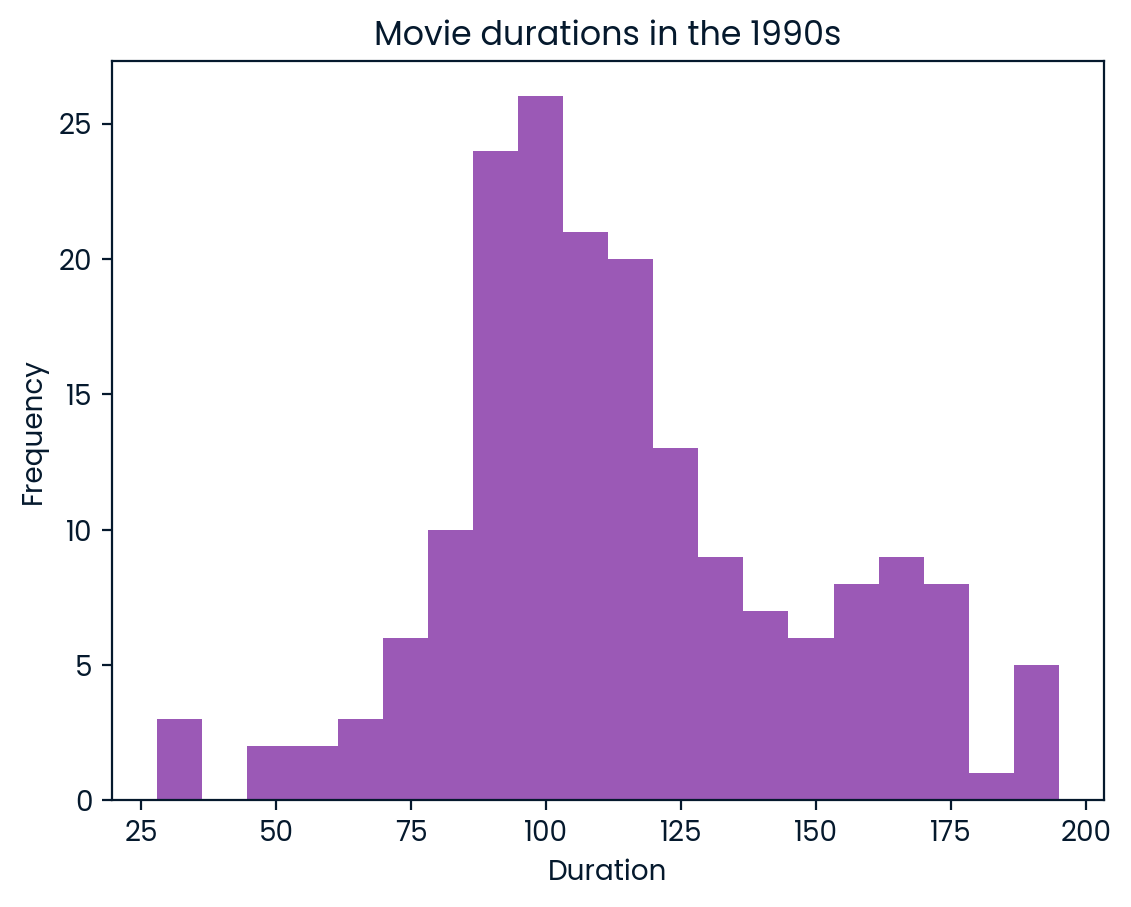

The most frequent duration is  94  mins


In [44]:
# Finding the most frequent movie duration
duration_counts = movies_90s['duration'].value_counts()
duration = duration_counts.idxmax()

# Visualizing the results
plt.hist(movies_90s['duration'], bins=20, color="#9B59B6")
plt.xlabel('Duration')
plt.ylabel('Frequency')
plt.title("Movie durations in the 1990s")
plt.show()

# Conclusion
print('The most frequent duration is ', duration, ' mins')

## 2. How many short action movies were released in the 1990s?

In [47]:
# Subsetting by genre and duration
short_action_movies = movies_90s[
    (movies_90s['duration'] < 90) &
    (movies_90s['genre'] == 'Action')
]

# Counting short action movies
short_movie_count = len(short_action_movies)
        
# Printing out the answer
print('The number of short action movies is: ', short_movie_count)

The number of short action movies is:  7


## 3. How does the average movie duration vary by genre in the 1990s?

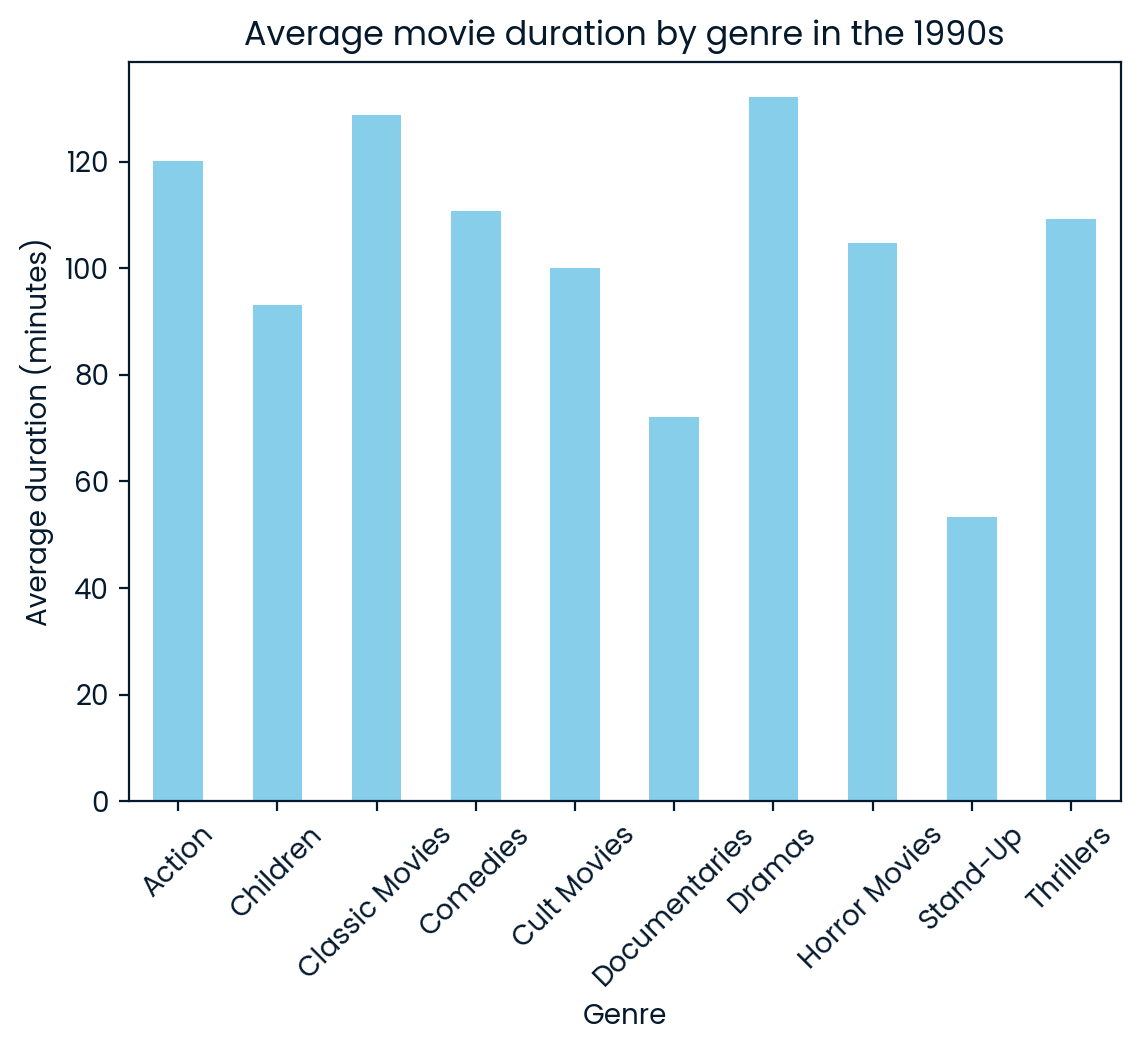

Average movie duration by genre:
genre
Action            120.145833
Children           93.066667
Classic Movies    128.733333
Comedies          110.700000
Cult Movies       100.000000
Documentaries      72.000000
Dramas            132.045455
Horror Movies     104.750000
Stand-Up           53.250000
Thrillers         109.200000
Name: duration, dtype: float64


In [50]:
# Investigating average movie duration by genre
genre_duration = movies_90s.groupby("genre")["duration"].mean()

# Visualizing the results
genre_duration.plot(kind="bar",color="skyblue")
plt.xlabel("Genre")
plt.xticks(rotation=45)
plt.ylabel("Average duration (minutes)")
plt.title("Average movie duration by genre in the 1990s")
plt.show()

# Printing out the answer
print("Average movie duration by genre:")
print(genre_duration)


## 4. How many movies were released in each year of the 1990s?

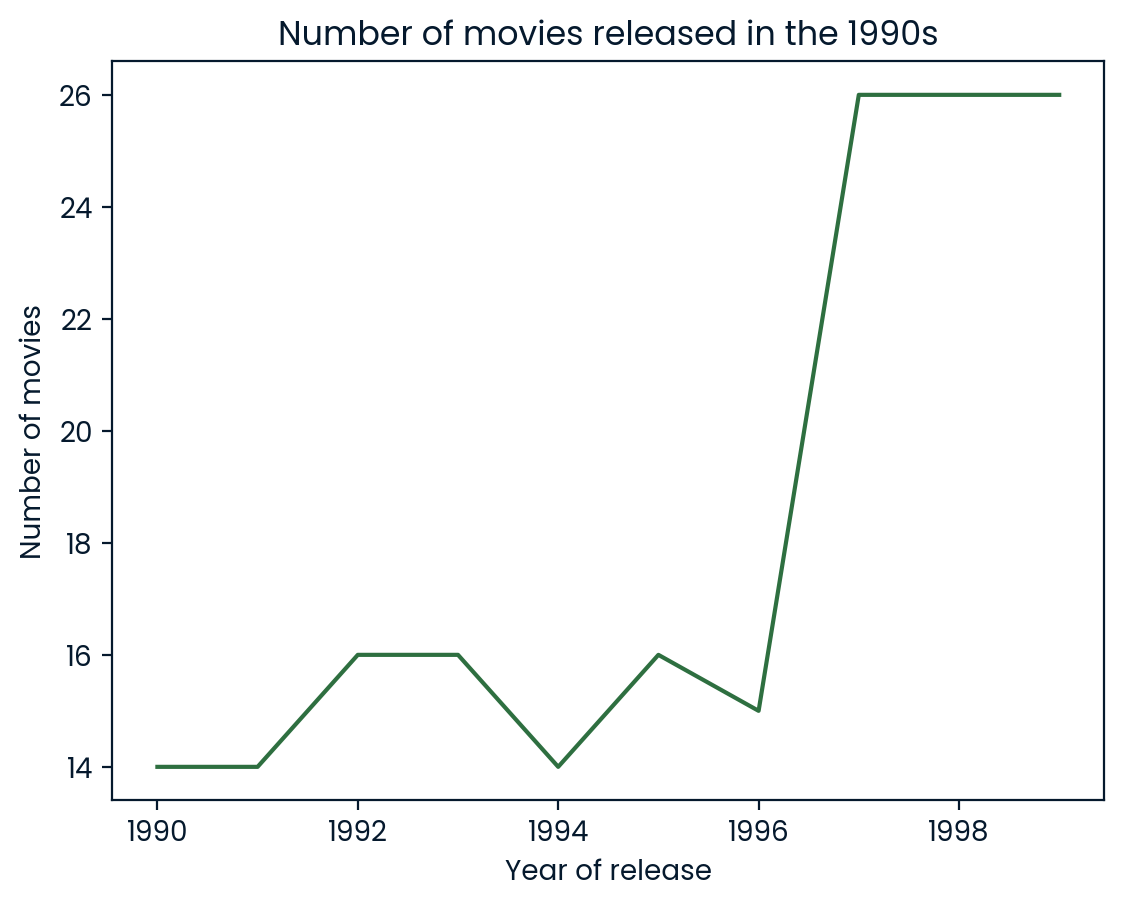

Number of movies released each year:
release_year
1990    14
1991    14
1992    16
1993    16
1994    14
1995    16
1996    15
1997    26
1998    26
1999    26
Name: title, dtype: int64


In [49]:
# Counting movies released in each year
movies_per_year = movies_90s.groupby("release_year")["title"].count()

# Visualizing the results
movies_per_year.plot(kind="line", color="#2E6F40")
plt.xlabel("Year of release")
plt.ylabel("Number of movies")
plt.title("Number of movies released in the 1990s")
plt.show()

# Printing out the results
print("Number of movies released each year:")
print(movies_per_year)